In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

This notebook performs manual cell type annotation mapping in a non-automatic manner from a reference dataset to a query dataset. (more easily interpretable and robust). In addition, it maps manually-curated markers on the query data.
Original query and reference data are available as .h5ad files is available on request (query dataset by: Sheikh Lab Helmholtz Munich, reference dataset by: Bhardwaj Lab (vlab), Utrecht University). The query dataset file countains the original integrated scVI embedding and all other data as at the time of analysis (for reproducibility).
Reference data: time series of gastruloids (single-cell VASAseq, full-length RNAseq)
Query data: embryoids treated with retinoic acid at different concentrations

In [5]:
# alldata1 = sc.read_h5ad('alldata.h5ad') #open query data 
#as Anndata object
alldata.var.index = alldata.var["gene_name"]# change .var DataFrame index in order to visualise gene names on embedding UMAP plots
alldata = alldata [:, ~alldata.var_names.duplicated(keep='first')].copy() # remove duplicates for scanpy DE preliminary marker identification
alldata.X=alldata.layers['log1p_norm'] # scanpy DE uses log1p-normalised counts

We also remove the .raw attribute of the object, if present, as .var index can transfer to the current object. (.var index is usually gene IDs, in our case - Ensembl IDs, but we need gene symbols).

In [6]:
del alldata.raw # delete only the .raw attribute from the object

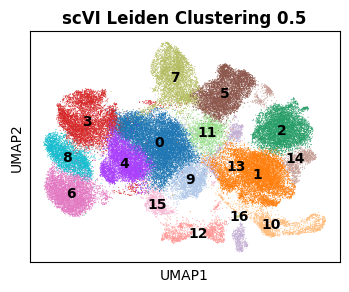

In [7]:
#----OPTIONAL---- to view query embedding
fig, ax = plt.subplots(figsize=(4,3))
sc.pl.umap(alldata, color=['scVI_res_0.5'], legend_loc='on data', show=False, ax=ax)
ax.set_title('scVI Leiden Clustering 0.5', fontsize=12, weight='bold')
plt.show()


Here we perform annotation using DE markers identified with sc.rank_genes_groups() with groups parameter set to None and groupby=clustering which means that markers for all clusters are returned. We need to extract the top 25 markers for the dataset for the given cluster for which we have to make sure that the output of the algorithm is ranked (based on a rank metric considering significance values and log2fold changes). 
Only top highly-expressed genes are selected for markers in both datasets: the top lowly expressed genes were the same group of genes at analysis, simply showing up in different clusters.

In [8]:
    # Code snippet by:
    # Heumos, L., Schaar, A.C., Lance, C. et al. Best practices for single-cell analysis across modalities. Nat Rev Genet 24, 550–572 (2023). 
    # DOI: https://doi.org/10.1038/s41576-023-00586-w
    # with modifications by mariakaraboeva

def get_stats(t_stats):
    '''
    Creates ranked list of scanpy-identified DE marker genes and replaces adjusted p-values of 0 with 1e-300 so that the rank calculation goes through.

    Args:
        t_stats (pd.DataFrame): output dataframe from sc.rank_genes_groups() optimised for current versions' column names.

    Returns:
        pd.DataFrame: ranked dataframe with gene names and ranked by the combined effect of log2foldchanges and p-adj values, with only two columns of 
        names and ranks.
    '''
    epsilon = 1e-300 
    t_stats['pvals_adj'] = t_stats['pvals_adj'].replace(0, epsilon) # remove p-adj values of 0 so that the log-transformation works
    t_stats['rank']=-np.log10(t_stats.pvals_adj)*t_stats.logfoldchanges # rank metric considering significance and effect size
    t_stats = t_stats.sort_values('rank', ascending=False) 
    t_stats.reset_index(inplace=True) 
    rank_stats = t_stats[['names', 'rank']] # extract only valuable columns
    return rank_stats

The markers with sc.rank_gene_groups are preliminary DE genes which are inly used for annotation, but not for DE analysis (where we applied pseudobulk)

In [9]:
sc.tl.rank_genes_groups(alldata, groupby='scVI_res_0.5', method='t-test', key_added='t-test', gene_symbols='gene_name', use_raw=False)
query_groups = sc.get.rank_genes_groups_df(alldata, group=None, key="t-test")

# Optional, see top markers on their own
# sc.pl.rank_genes_groups(alldata, n_genes=25, gene_symbols='gene_name', sharey=False, key="t-test", save='25_genes.png', use_raw=None, layer='log1p_norm')

In [12]:
# alldata.uns

Here we can visualise the top 5 markers per cluster as a dotplot

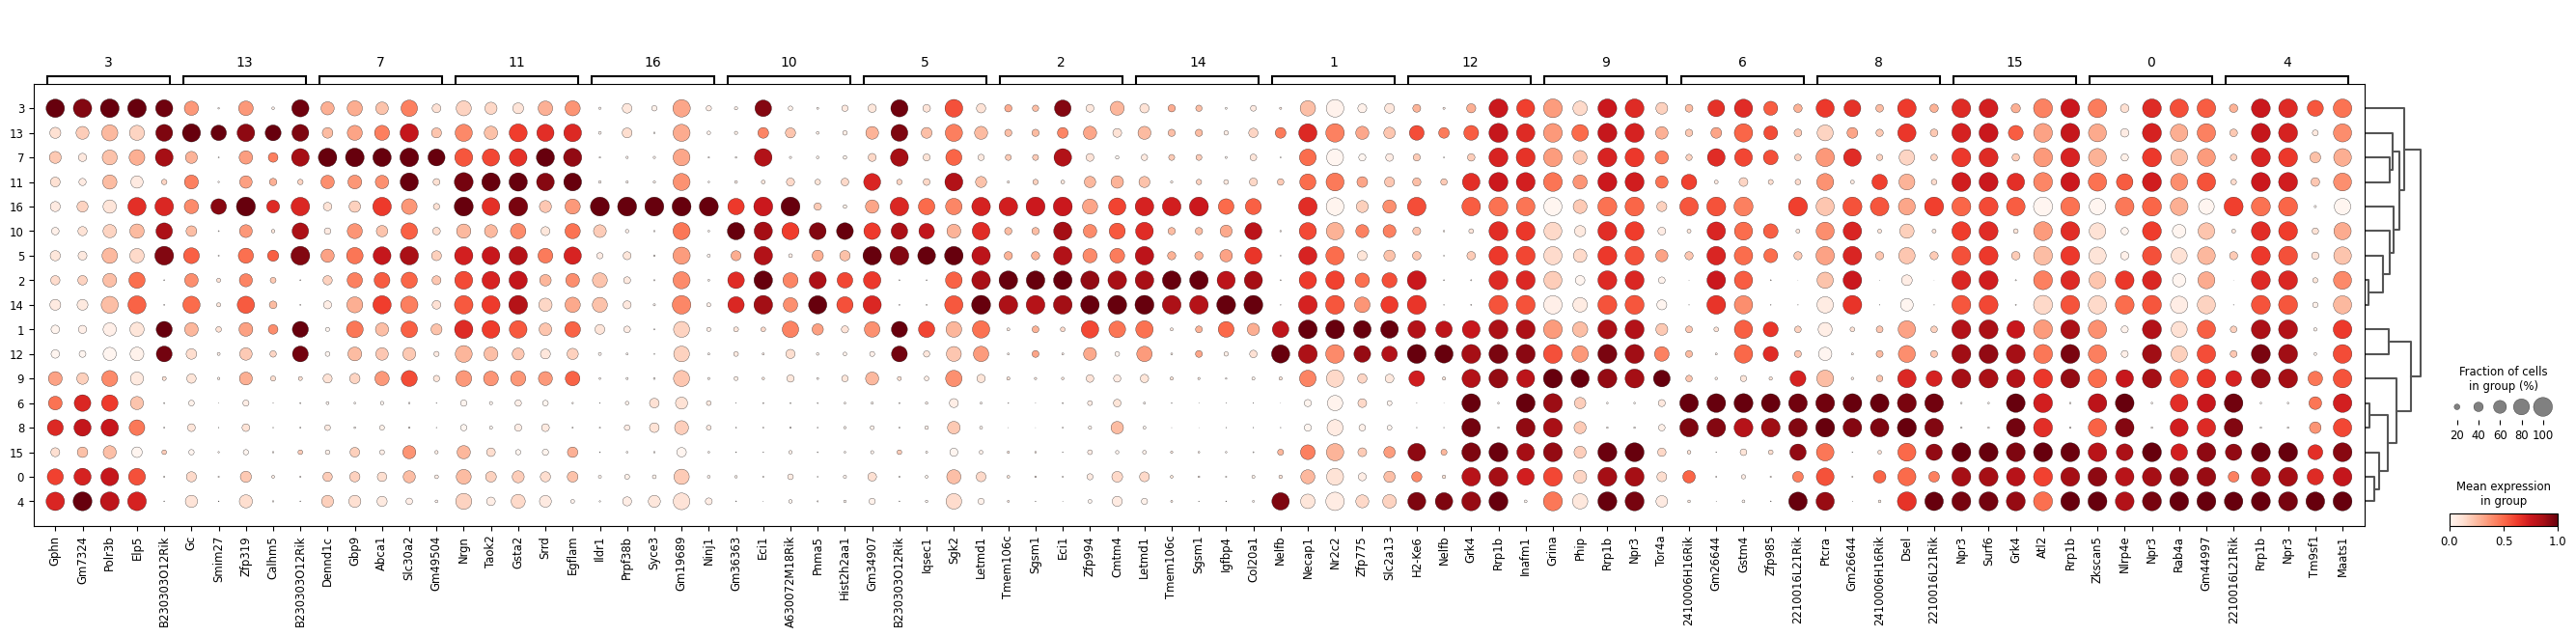

In [13]:
sc.pl.rank_genes_groups_dotplot(alldata, groupby='scVI_res_0.5', key='t-test',standard_scale='var', layer='log1p_norm', save='dotplot_markers.png', n_genes=5)
# this will save to figures/dotplot_markers.png in wd

In [ ]:
query_groups

The reference dataset was in backed mode and did not load all components of the object (for example, UMAP coordinates). Therefore we load it to memory.

In [32]:
theirdata = sc.read_h5ad('Anndata_Objects/theirdata.h5ad') 
theirdata=theirdata.to_memory()
theirdata = theirdata.copy()
theirdata.var_names=theirdata.var['Symbol'] # change var names to gene symbols

In [18]:
from pandas.errors import PerformanceWarning 
warnings.filterwarnings("ignore", category=PerformanceWarning)

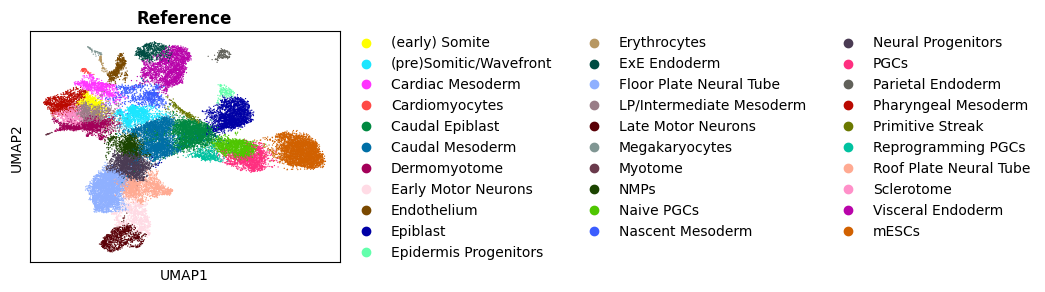

In [15]:
fig, ax = plt.subplots(figsize=(4,3))
sc.pl.umap(theirdata, color=['celltype'], show=False, ax=ax)
ax.set_title('Reference', fontsize=12, weight='bold')
plt.show()

We obtain the cell type markers of the ref dataset 

In [19]:
sc.tl.rank_genes_groups(theirdata, groupby='celltype', method='t-test', key_added='t-test', gene_symbols='Symbol')
ref_groups = sc.get.rank_genes_groups_df(theirdata, group=None, key="t-test")

In [20]:
ref_celltype = theirdata.obs['celltype'].unique().tolist() #unique reference cell types
query_celltype = alldata.obs['scVI_res_0.5'].unique().tolist() # unique cluster numbers


Here we also read our dataframe of curated markers for every expected cell type in the dataset. The gene columns for the cell types can be of different lengths - then we make sure we remove NaN values later when we extract the gene names.

In [21]:
curated_markers=pd.read_csv('Tables/Annotation_Markers/supplementary_table_02_mariakaraboeva_5244943.csv') #read markers df

In [22]:
curated_markers.head(10)

,Trophoectoderm,PE,Epiblast,Neural progenitors,Cardiac Mesoderm,Glia,Differentiated neurons,Ventral neurons,Spinal cord,Hindbrain,...,Retinoyated proteins,Pluripotency,Primitive streak,Nascent mesoderm,gr state mESCs,naiive mESCs,could be AVE Endoderm,Definitive endoderm,EMT,Paraxial mesoderm
0,Cdx2,Gata4,Nodal,Ngn2,Nkx2.5,Gfap,Tubb3,Dlx1,Hb9,Gbx2,...,p51,Cxcl5,T,Cdh2,Tfcp2l1,Mycn,Cer1,Mixl1,Cdh11,Msgn1
1,Gata3,NaN,Tdgf1,Sox1,Fzd2,p16330,Isl1,Gbx2,Lim3,Hoxb1,...,p55,Dnmt3b,Meox1,Vim,Tbx3,Zscan4,Lefty1,Foxa2,Fsp1,Meox1
2,Tead4,NaN,Col18a1,Sox2,Tbx5,Cnp,Isl2,Olig3,Gli1,Hoxa2,...,Vim,Hesx1,Kdr,Twist,Tcl1,Tcfcp2l1,Dkk1,Sox17,Vim,Tcf15
3,P63,NaN,Cxcl12,Sox3,Tbx20,Mog,Tuj1,Olig2,Gli3,Hoxa3,...,Krt16,Ido1,Mixl1,Snai1,Dazl,Sox21,Alk2,Cxcr4,Twist,Pax3
4,Eomes,NaN,Cdh1,Nes,Gata6,Mag,Lmx1b,Shh,Hes1,Phox2b,...,Krt10,Lck,Sox17,Zeb,Prdm14,Prdm14,Alk3,Gsc,Lef1,Pax7
5,Gata2,NaN,Fgf5,Olig2,Hand2,Mbp,Tph2,Dbx1,Foxn4,Hoxc4,...,Mpp2,Nanog,Foxa2,Fn1,Prdm1,Esrrb,Bmpr2,Wnt5a,Fts1,Myog
6,Essrb,NaN,Fgf4,Otx1,Actg1,S100b,Fev,Dbx2,Lmx1b,Hoxc5,...,Mpp4,Pouf5f1,Eomes,Ddr2,Kit,Rex1,Hex,Gli1,Itga5,Wnt3
7,Dlx3,NaN,Prdm14,Dcc,Actb,Sox9,Nkx2b,Evx1,Evx1,Hoxc6,...,Maguk,Sox2,Wnt3,Tbx6,Dppa3,Zfp42,Hex,Hhex,Itgav,Msx1
8,Rxra,NaN,Klf2,Gadd45g,Acta2,Nf1a,Ebf1,Evx2,Vsx2,Hoxc8,...,Fcgrt,Trim22,Wnt3a,Msx1,Stella,Pecam1,Cer1,Otx2,Sdc1,Cdx2
9,Pparg,NaN,Klf4,Elovl3,Vsnl1,Aldh1l1,Pax2,En,Gsx2,Hoxc10,...,NaN,NaN,Gsc,Sp5,Lefty1,Tcl1,Lhx1,Klf6,Ctnnb1,NaN


Here we simply define a function to plot each gene (in normalised counts) on the (the reference or query) embedding if the gene is indeed present in the data.

In [27]:
def plot_embeddings(dataset, folder, gene_names, tissue):
    '''
    Plotting function called by mapping() which produces UMAP embeddings.

    Args:
        (passed from mapping()):
        dataset (Anndata object)
        folder (str): folder names: 'all' (ref-query), 'their' (query-ref), (plotting own markers (optional))'all_own', 'their_own' and 'markers' (curated markers)
        (own, takes from mapping()):
        gene_names (list): list of str, gene symbols of genes to plot 
        
    Returns:
        None
        
    '''
    for gene in gene_names:
        if gene in dataset.var_names:
            fig, ax = plt.subplots(figsize=(4,3))
            sc.pl.umap(dataset, color=gene, cmap='Reds', show=False, ax=ax)
            ax.set_title(f'{tissue} - {gene}', fontsize=12, weight='bold')
            # plt.savefig(f'{folder}/{gene}_{tissue}.png', dpi=300, bbox_inches='tight') 
            plt.show()

This function allows for mapping of genes in all of the following ways: plotting query genes on the reference dataset or reference genes on the query dataset; also plotting query/ref genes on their own embeddings. We cross-plotted only the top highly expressed marker genes for both reference and the query since the most downregulated genes showing up were the same genes as the highly regulated, just in other clusters, confirming the cluster-specific expression of these markers in their source datasets as identified by sc.rank_genes_groups(). 
The function also plots the curated gene markers.

In [28]:
def mapping(dataset, all_groups, celltype, folder):
    '''
    Produce plots mapping marker genes both ways from reference to query or plot markers on the query dataset. Also plot dataset's own markers on its
    own embedding. Optimised for markers identified by sc.get.rank_genes_groups().

    Args:
        dataset (Anndata object): Anndata object with .X as log-normalised counts for plotting and index as gene symbols. Both reference and query
        should have index as gene symbols. var_names should not have duplicated items. Also passed to plot_embeddings()
        all_groups (pd.DataFrame): output of sc.get.rank_genes_groups_df(group=None). A single dataframe which can be seen as composed of dataframes for
        every celltype. There is a single column "group" with multiple rows grouped by cell type.
        celltype (list or pd.DataFrame): the source object which can be either list of cell type/cluster labels in the dataset or a dataframe containing
        manually curated markers. 
        folder (str): folder name where to store embeddings. Also passed to plot_embeddings().

    Returns:
        None
    '''
    if type(celltype)== list:     # We either iterate through the cluster/cell type markers
        for c in celltype: 
            df=all_groups[all_groups["group"] == c] # get celltype specific df
            df=(get_stats(df)) # extract ranked markers
            gene_names = df.head(25)['names'].tolist() 
            plot_embeddings(dataset, folder, gene_names, c) 
    elif type(celltype)==pd.DataFrame:     # or the dataframe with curated markers
        for tissue in celltype.columns:
            gene_names=celltype[tissue].dropna().tolist()
            print(gene_names)
            plot_embeddings(dataset, folder, gene_names, tissue)

In [37]:

from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings("ignore", category=SettingWithCopyWarning)

We show the figures here just as an example otherwise showing is memory-intensive

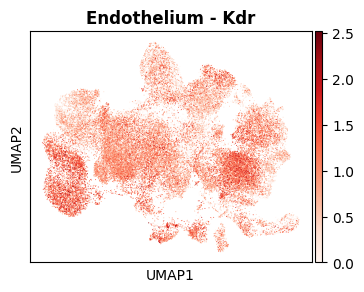

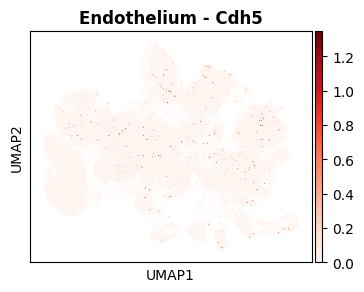

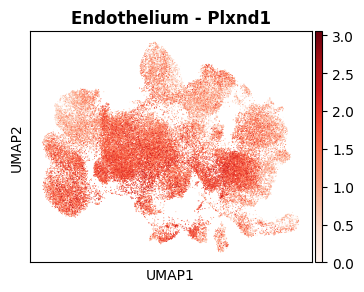


KeyboardInterrupt



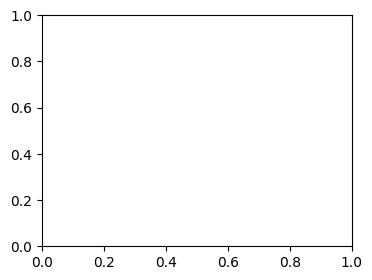

In [38]:
mapping(alldata, ref_groups, ref_celltype, 'ref_to_query') #Example call producing reference to query mapping embeddings
# mapping(theirdata, query_groups, query_celltype, 'query_to_ref') #Example call producing ref to query mapping embeddings
# mapping(theirdata, ref_groups, ref_celltype, 'ref_to_ref')
# mapping(alldata, query_groups, query_celltype, 'query_to_query')

In [ ]:
mapping(alldata, query_groups, curated_markers, 'markers') #mapping curated markers

When we do cross-mapping between query and ref datasets it is important to visualise how this gene maps on its source dataset: this can reveal that it is expressed in more than one clusters there even if its "top" cluster is "Neurons" for example. This is why we plot genes also on the source datasets. 
Next, we assign the annotation labels

In [30]:
labels = {
    '0': 'Naive\nPluripotent',
    '1': 'Cardiac-like\nMesoderm',
    '2': 'Differentiating\nNeurons',
    '3': 'Epiblast\nPrimitive Streak',
    '4': 'Primed\nPluripotent',
    '5': 'Neural\nProgenitors',
    '6': 'Pluripotent1',
    '7': 'Mesoderm',
    '8': 'Pluripotent2',
    '9': 'Epiblast\nEpidermis',
    '10': 'Hemato-endothelial\nProgenitors 1',
    '11': 'N/A1',
    '12': 'N/A2',
    '13': 'N/A3',
    '14': 'N/A4',
    '15': 'Endoderm',
    '16': 'Contamination'
}

alldata.obs["manual_celltype_annotation"] = alldata.obs['scVI_res_0.5'].map(labels)


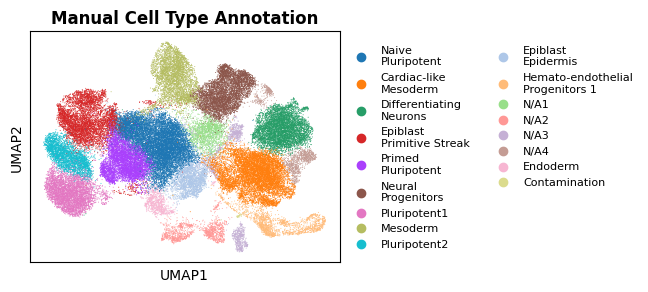

In [31]:
fig, ax = plt.subplots(figsize=(4,3))
sc.pl.umap(
    alldata,
    color=["manual_celltype_annotation"],
    legend_fontsize=8,
    na_color="gray",
    use_raw=False,
    layer='log1p_norm',
    show = False,
    ax=ax
)
ax.set_title(f'Manual Cell Type Annotation', fontsize=12, weight='bold')
plt.savefig(f'annotation/manual_annotation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
alldata.write_h5ad('annotated/alldata.h5ad', compression="gzip")

References:
1.Heumos, L., Schaar, A.C., Lance, C. et al. Best practices for single-cell analysis across modalities. Nat Rev Genet 24, 550–572 (2023). https://doi.org/10.1038/s41576-023-00586-w
2.Cross-plotting at the suggestion of V. Bhardwaj github: bhardwaj-lab